# E-Commerce EDA & Customer Segmentation (RFM)

This notebook explores the cleaned Online Retail dataset (`cleaned_online_retail_data_v1.csv`, produced in `cleaning.ipynb`) and builds toward an actionable customer segmentation.

**What this notebook covers:**
1. Data loading & feature engineering
2. Revenue trends over time
3. Order timing patterns (hour of day / day of week)
4. Geographic revenue breakdown
5. Top products
6. Customer revenue concentration (Pareto / 80-20 rule)
7. RFM segmentation (Recency, Frequency, Monetary)
8. RFM scoring & customer segments
9. Repeat-purchase behavior of top customers
10. Key takeaways


## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

sns.set_theme(style='whitegrid')


In [2]:
df = pd.read_csv('cleaned_online_retail_data_v1.csv')
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392692 entries, 0 to 392691
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0       InvoiceNo  392692 non-null  int64  
 1   StockCode      392692 non-null  object 
 2   Description    392692 non-null  object 
 3   Quantity       392692 non-null  int64  
 4   InvoiceDate    392692 non-null  object 
 5   UnitPrice      392692 non-null  float64
 6   CustomerID     392692 non-null  int64  
 7   Country        392692 non-null  object 
dtypes: float64(1), int64(3), object(4)
memory usage: 24.0+ MB


## 2. Feature Engineering

Data is already cleaned (missing `CustomerID` dropped, duplicates checked, negative/zero `Quantity`/`UnitPrice` removed — see `cleaning.ipynb`). Here we just derive the fields the analysis needs.

In [3]:
df.columns = df.columns.str.strip()

In [4]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['TotalSpend'] = df['Quantity'] * df['UnitPrice']

df['YearMonth'] = df['InvoiceDate'].dt.to_period('M').astype(str)
df['Hour'] = df['InvoiceDate'].dt.hour
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()

df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSpend,YearMonth,Hour,DayOfWeek
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010-12,8,Wednesday
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,8,Wednesday
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010-12,8,Wednesday
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,8,Wednesday
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,8,Wednesday


## 3. Revenue Trends Over Time

Total revenue by month, to spot seasonality .

In [7]:
monthly_sales = df.groupby('YearMonth')['TotalSpend'].sum().reset_index()
monthly_sales.sort_values('TotalSpend', ascending=False, inplace=True)
monthly_sales

,YearMonth,TotalSpend
11,2011-11,1156205.610
10,2011-10,1035642.450
9,2011-09,950690.202
5,2011-05,677355.150
6,2011-06,660046.050
8,2011-08,644051.040
7,2011-07,598962.901
3,2011-03,594081.760
0,2010-12,570422.730
1,2011-01,568101.310


C:\Users\abbes\AppData\Local\Temp\ipykernel_29316\2686893122.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=monthly_sales, x='YearMonth', y='TotalSpend', palette='viridis', ax=ax)


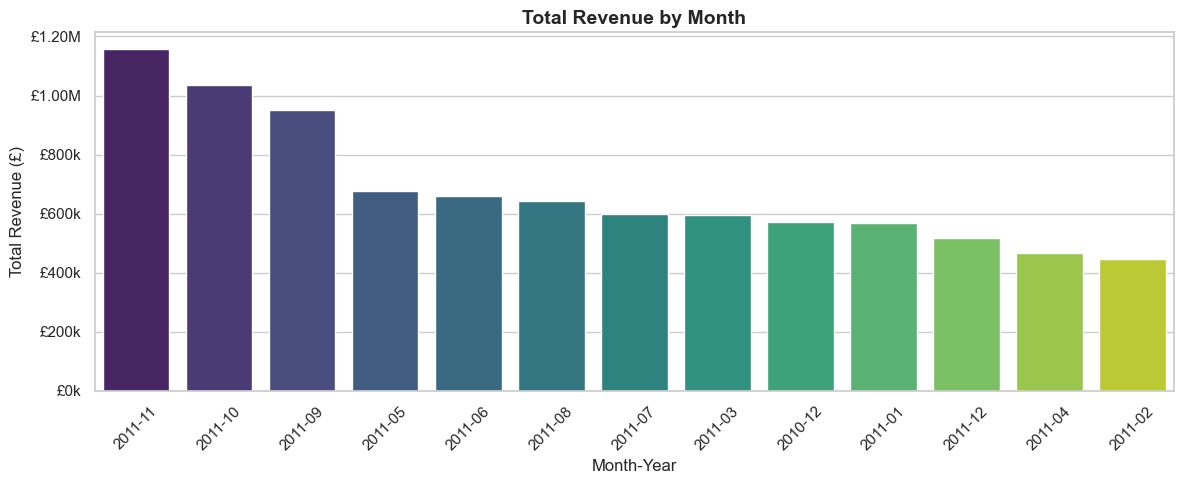

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=monthly_sales, x='YearMonth', y='TotalSpend', palette='viridis', ax=ax)

ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'£{x*1e-3:,.0f}k' if x < 1e6 else f'£{x*1e-6:,.2f}M')
)

plt.title('Total Revenue by Month', fontsize=14, fontweight='bold')
plt.xlabel('Month-Year', fontsize=12)
plt.ylabel('Total Revenue (£)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Conclusion:** Revenue is clearly seasonal — **November 2011 was the strongest month** at £1.16M, about **69% above** the ~£684k monthly average, consistent with pre-Christmas buying. October and September follow the same build-up (£1.04M and £951k). The weakest months are February (£446k) and April (£468k). December 2011 looks low (£517k) only because the dataset cuts off mid-month, not because of an actual drop. → Plan inventory and marketing spend around the Sep–Nov ramp-up.

## 4. Order Timing Patterns

When do customers place orders — which hours of the day and which days of the week are busiest?

In [9]:
hourly_orders = df.groupby('Hour')['InvoiceNo'].nunique().reset_index().sort_values('InvoiceNo', ascending=False)
hourly_orders 

,Hour,InvoiceNo
6,12,3130
7,13,2636
5,11,2277
8,14,2274
4,10,2226
9,15,2037
3,9,1393
10,16,1100
2,8,555
11,17,544


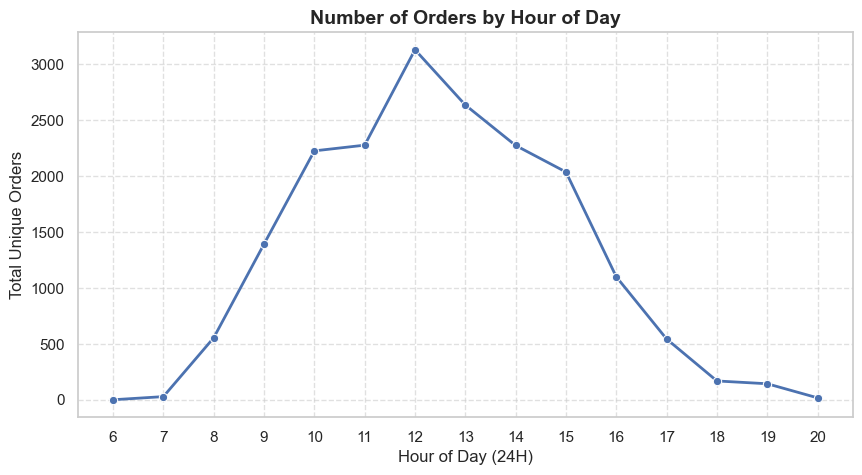

In [10]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=hourly_orders.sort_values('Hour'), x='Hour', y='InvoiceNo', marker='o', color='b', linewidth=2)

plt.title('Number of Orders by Hour of Day', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day (24H)', fontsize=12)
plt.ylabel('Total Unique Orders', fontsize=12)
plt.xticks(range(6, 21))
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


In [11]:
days_orders = df.groupby('DayOfWeek')['InvoiceNo'].nunique().reset_index().sort_values('InvoiceNo', ascending=False)
days_orders 

,DayOfWeek,InvoiceNo
3,Thursday,4032
5,Wednesday,3455
4,Tuesday,3184
1,Monday,2863
0,Friday,2829
2,Sunday,2169


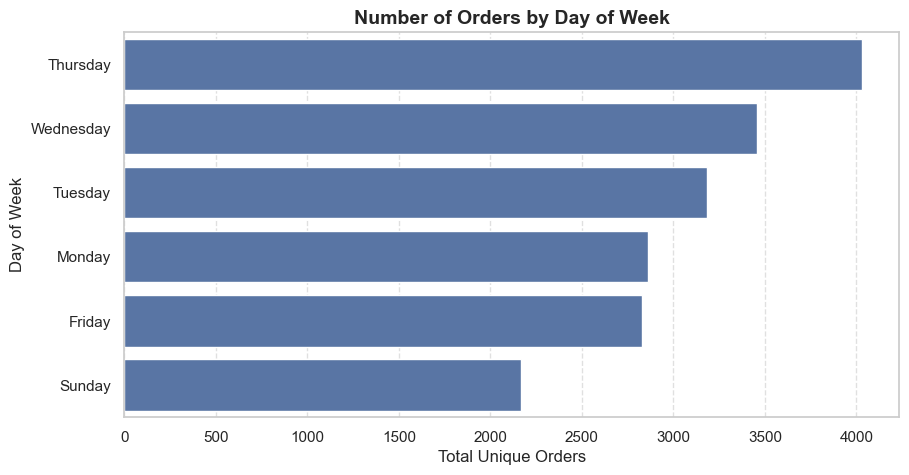

In [13]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=days_orders,
    x='InvoiceNo',
    y='DayOfWeek'
)

plt.title('Number of Orders by Day of Week', fontsize=14, fontweight='bold')
plt.xlabel('Total Unique Orders', fontsize=12)
plt.ylabel('Day of Week', fontsize=12)

plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.show()

**Conclusion:** Orders concentrate heavily in a narrow midday window — **10am–3pm**, peaking at **noon (3,130 orders)**. Almost nothing happens before 8am or after 6pm. By day, **Thursday is busiest (4,032 orders)**, and **Sunday is quietest (2,169)** — notably, there's **no Saturday data at all**, meaning this business doesn't take orders on Saturdays. → Time-sensitive promotions or customer support staffing should center on weekday late-mornings.

## 5. Geographic Revenue Breakdown

Which countries generate the most revenue?

In [15]:
country_sales = (
    df.groupby('Country')['TotalSpend']
    .sum()
    .reset_index()
    .sort_values('TotalSpend', ascending=False)
)
top_countries = country_sales.head(10)
top_countries


,Country,TotalSpend
35,United Kingdom,7285024.644
23,Netherlands,285446.340
10,EIRE,265262.460
14,Germany,228678.400
13,France,208934.310
0,Australia,138453.810
30,Spain,61558.560
32,Switzerland,56443.950
3,Belgium,41196.340
31,Sweden,38367.830


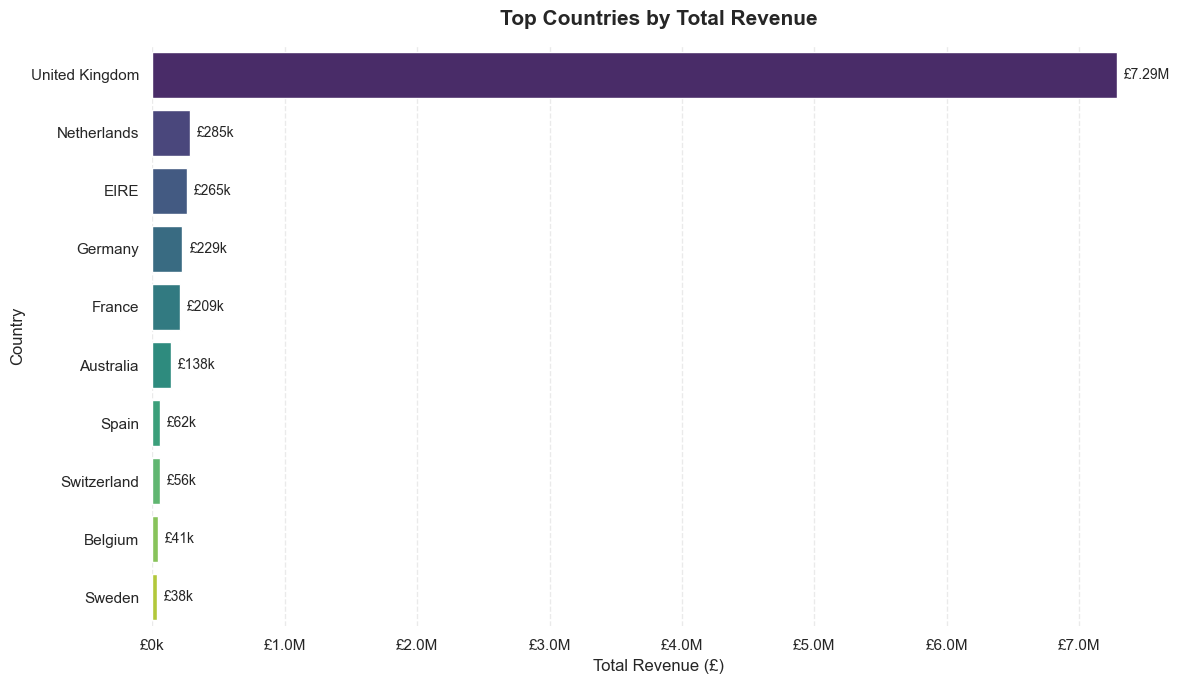

In [16]:
fig, ax = plt.subplots(figsize=(12, 7))

sns.barplot(
    data=top_countries,
    x='TotalSpend', y='Country',
    hue='Country', legend=False, palette='viridis', ax=ax
)

ax.xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'£{x/1e6:.1f}M' if x >= 1e6 else f'£{x/1e3:.0f}k')
)

ax.set_title('Top Countries by Total Revenue', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Total Revenue (£)', fontsize=12)
ax.set_ylabel('Country', fontsize=12)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt=lambda x: f'£{x/1e6:.2f}M' if x >= 1e6 else f'£{x/1e3:.0f}k',
        padding=5, fontsize=10
    )

ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.grid(axis='y', visible=False)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()


**Conclusion:** The business is overwhelmingly UK-driven — **United Kingdom accounts for £7.29M, ~82% of total revenue**, and outsells the next-largest market (Netherlands, £285k) . The remaining top-10 countries (EIRE, Germany, France, Australia, Spain, Switzerland, Belgium, Sweden) each contribute under 3.5% individually. → International revenue is a long tail, not a second pillar; any growth strategy targeting geographic diversification is starting from a very small base.

## 6. Top Products

Best-selling products by total quantity sold.

In [17]:
top_products = (
    df.groupby('Description')['Quantity']
    .sum()
    .reset_index()
    .sort_values('Quantity', ascending=False)
    .head(10)
)
top_products


,Description,Quantity
2310,"PAPER CRAFT , LITTLE BIRDIE",80995
1982,MEDIUM CERAMIC TOP STORAGE JAR,77916
3775,WORLD WAR 2 GLIDERS ASSTD DESIGNS,54319
1751,JUMBO BAG RED RETROSPOT,46078
3687,WHITE HANGING HEART T-LIGHT HOLDER,36706
206,ASSORTED COLOUR BIRD ORNAMENT,35263
2260,PACK OF 72 RETROSPOT CAKE CASES,33670
2588,POPCORN HOLDER,30919
2644,RABBIT NIGHT LIGHT,27153
2037,MINI PAINT SET VINTAGE,26076


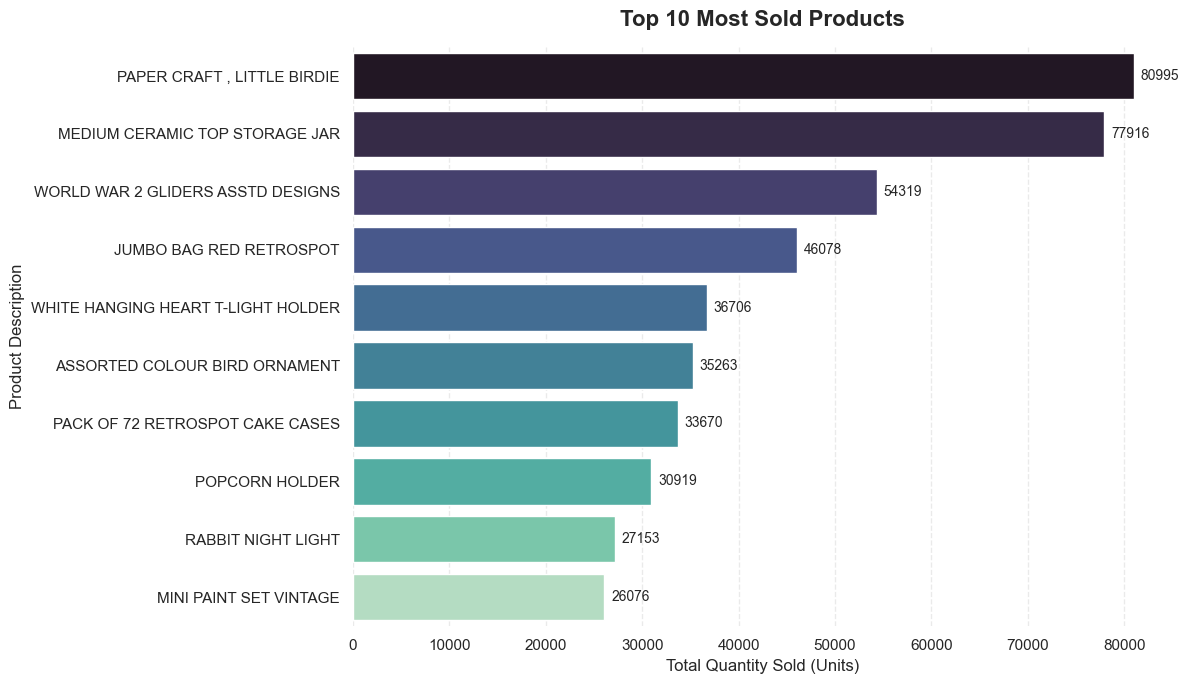

In [18]:
fig, ax = plt.subplots(figsize=(12, 7))

sns.barplot(
    data=top_products,
    x='Quantity', y='Description',
    hue='Description', legend=False, palette='mako', ax=ax
)

ax.set_title('Top 10 Most Sold Products', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Total Quantity Sold (Units)', fontsize=12)
ax.set_ylabel('Product Description', fontsize=12)

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=5, fontsize=10)

ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.grid(axis='y', visible=False)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()


## 7. Customer Revenue Concentration (Pareto / 80-20 Rule)

How much of total revenue comes from a small share of customers?

In [19]:
customer_spend = (
    df.groupby('CustomerID')['TotalSpend']
    .sum()
    .sort_values(ascending=False)
)

total_revenue = customer_spend.sum()
total_customers = len(customer_spend)

cumulative_revenue_pct = (customer_spend.cumsum() / total_revenue) * 100
customer_percentage = (np.arange(1, total_customers + 1) / total_customers) * 100


In [20]:
percentages = [20, 40, 60, 80, 100]
pareto_summary = []

for pct in percentages:
    n_customers = int(np.ceil(total_customers * pct / 100))
    cum_revenue = customer_spend.iloc[:n_customers].sum()
    revenue_pct = (cum_revenue / total_revenue) * 100

    pareto_summary.append({
        'Customer %': pct,
        'Customers': n_customers,
        'Cumulative Revenue (£)': cum_revenue,
        'Cumulative Revenue %': revenue_pct
    })

pareto_summary = pd.DataFrame(pareto_summary)
pareto_summary


,Customer %,Customers,Cumulative Revenue (£),Cumulative Revenue %
0,20,868,6637300.821,74.683749
1,40,1736,7851694.991,88.348266
2,60,2603,8444767.413,95.021592
3,80,3471,8755019.724,98.512591
4,100,4338,8887208.894,100.000000


In [21]:
top_20 = pareto_summary.iloc[0]

print(f"Top 20% of customers: {top_20['Customers']:,}")
print(f"Cumulative revenue: £{top_20['Cumulative Revenue (£)']:,.2f}")
print(f"Revenue contribution: {top_20['Cumulative Revenue %']:.1f}%")


Top 20% of customers: 868.0
Cumulative revenue: £6,637,300.82
Revenue contribution: 74.7%


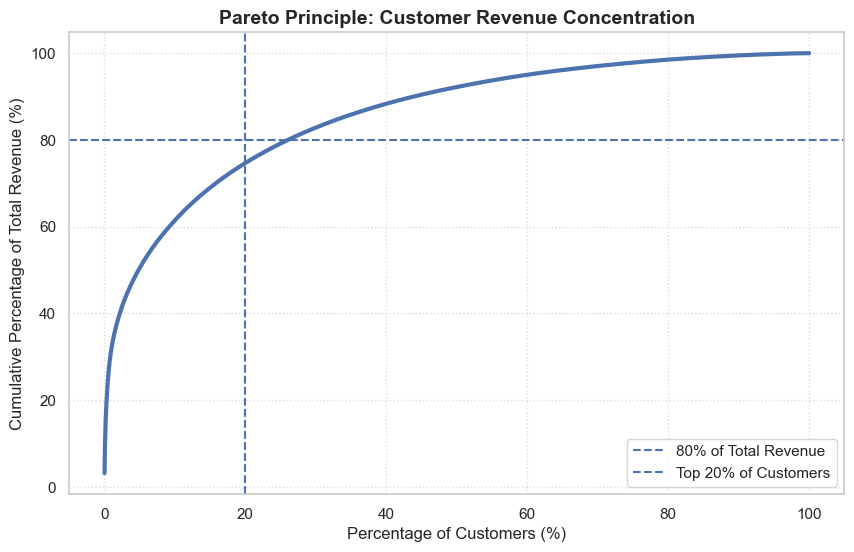

In [22]:
plt.figure(figsize=(10, 6))

sns.lineplot(x=customer_percentage, y=cumulative_revenue_pct, linewidth=3)
plt.axhline(y=80, linestyle='--', label='80% of Total Revenue')
plt.axvline(x=20, linestyle='--', label='Top 20% of Customers')

plt.title('Pareto Principle: Customer Revenue Concentration', fontsize=14, fontweight='bold')
plt.xlabel('Percentage of Customers (%)')
plt.ylabel('Cumulative Percentage of Total Revenue (%)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()


**Conclusion:** revenue relies heavily on a small group of highly valuable customers.

The VIPs: Just 20% of your customers (868 people) bring in 75% of total revenue.

The Drop-Off: The bottom 60% of your customer base barely moves the needle, contributing less than 5% combined.

To grow the business, we stop running broad marketing campaigns aimed at everyone. we need to Focus our  budget and retention efforts directly on keeping those top 868 buyers happy—they are the true financial engine of our company.

## 8. RFM Segmentation

**RFM** summarizes each customer along three dimensions:
- **Recency** — days since their last purchase (lower is better)
- **Frequency** — number of distinct orders (higher is better)
- **Monetary** — total amount spent (higher is better)


In [23]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

final_rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalSpend': 'sum'
}).rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalSpend': 'Monetary'
})

print('RFM table built —', len(final_rfm), 'customers')
final_rfm.head()


RFM table built — 4338 customers


,Recency,Frequency,Monetary
CustomerID,,,
12346,326,1,77183.60
12347,2,7,4310.00
12348,75,4,1797.24
12349,19,1,1757.55
12350,310,1,334.40


## 9. RFM Scoring & Customer Segments

Raw R/F/M numbers aren't directly comparable (days vs. order counts vs. £), so we score each dimension into quintiles (1 = worst, 5 = best) and combine the scores into named segments.

We rank before applying `qcut` so that ties (e.g. many customers with the same `Frequency`) don't break the binning.

In [24]:
# 1 = worst, 5 = best for every dimension.
# Recency is reversed: a LOW number of days (recent purchase) should score HIGH.
final_rfm['R_Score'] = pd.qcut(final_rfm['Recency'].rank(method='first'), 5, labels=[5, 4, 3, 2, 1]).astype(int)
final_rfm['F_Score'] = pd.qcut(final_rfm['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5]).astype(int)
final_rfm['M_Score'] = pd.qcut(final_rfm['Monetary'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5]).astype(int)

final_rfm['RFM_Score'] = (
    final_rfm['R_Score'].astype(str)
    + final_rfm['F_Score'].astype(str)
    + final_rfm['M_Score'].astype(str)
)
final_rfm['RFM_Sum'] = final_rfm[['R_Score', 'F_Score', 'M_Score']].sum(axis=1)

final_rfm.head()


,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Sum
CustomerID,,,,,,,,
12346,326,1,77183.60,1,1,5,115,7
12347,2,7,4310.00,5,5,5,555,15
12348,75,4,1797.24,2,4,4,244,10
12349,19,1,1757.55,4,1,4,414,9
12350,310,1,334.40,1,1,2,112,4


In [25]:
def segment_customer(row):
    r, f = row['R_Score'], row['F_Score']

    if r >= 4 and f >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'New Customers'
    elif r == 3 and f <= 2:
        return 'Promising'
    elif r <= 2 and f >= 4:
        return 'At Risk'
    elif r <= 2 and f == 3:
        return 'Needs Attention'
    else:
        return 'Hibernating / Lost'

final_rfm['Segment'] = final_rfm.apply(segment_customer, axis=1)
final_rfm[['Recency', 'Frequency', 'Monetary', 'RFM_Score', 'Segment']].head(10)


,Recency,Frequency,Monetary,RFM_Score,Segment
CustomerID,,,,,
12346,326,1,77183.60,115,Hibernating / Lost
12347,2,7,4310.00,555,Champions
12348,75,4,1797.24,244,At Risk
12349,19,1,1757.55,414,New Customers
12350,310,1,334.40,112,Hibernating / Lost
12352,36,8,2506.04,355,Loyal Customers
12353,204,1,89.00,111,Hibernating / Lost
12354,232,1,1079.40,114,Hibernating / Lost
12355,214,1,459.40,112,Hibernating / Lost


In [26]:
segment_summary = (
    final_rfm.groupby('Segment')
    .agg(
        Customers=('Segment', 'size'),
        Avg_Recency=('Recency', 'mean'),
        Avg_Frequency=('Frequency', 'mean'),
        Total_Revenue=('Monetary', 'sum')
    )
    .sort_values('Total_Revenue', ascending=False)
)
segment_summary['Revenue %'] = (segment_summary['Total_Revenue'] / segment_summary['Total_Revenue'].sum()) * 100
segment_summary


,Customers,Avg_Recency,Avg_Frequency,Total_Revenue,Revenue %
Segment,,,,,
Champions,1121,12.995540,10.051740,5857798.930,65.912695
Loyal Customers,821,37.188794,3.691839,1380847.521,15.537471
Hibernating / Lost,1074,216.675047,1.101490,523803.282,5.893901
At Risk,285,134.792982,4.887719,453355.700,5.101216
Needs Attention,376,162.656915,2.295213,370556.741,4.169551
Promising,351,52.504274,1.162393,158607.280,1.784669
New Customers,310,18.096774,1.245161,142239.440,1.600496


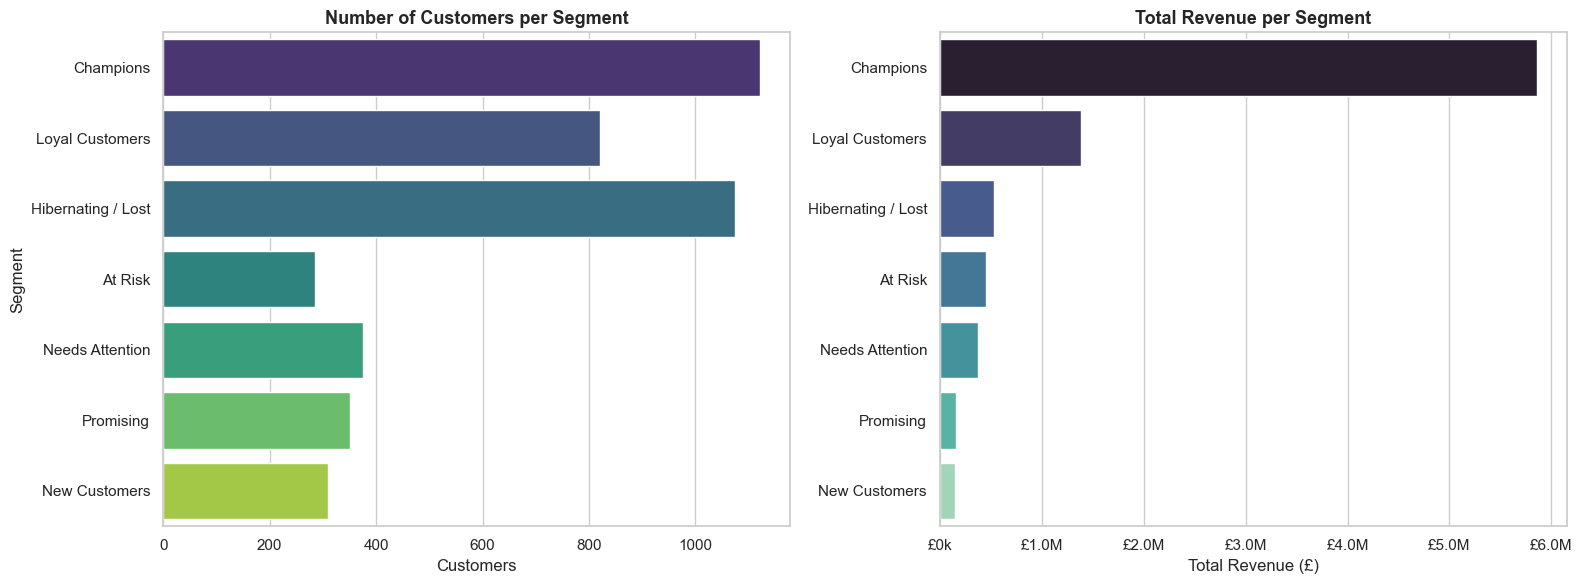

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

order = segment_summary.index

sns.barplot(
    x=segment_summary['Customers'], y=order,
    hue=order, legend=False, palette='viridis', ax=axes[0]
)
axes[0].set_title('Number of Customers per Segment', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Customers')
axes[0].set_ylabel('Segment')

sns.barplot(
    x=segment_summary['Total_Revenue'], y=order,
    hue=order, legend=False, palette='mako', ax=axes[1]
)
axes[1].xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'£{x/1e6:.1f}M' if x >= 1e6 else f'£{x/1e3:.0f}k')
)
axes[1].set_title('Total Revenue per Segment', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Total Revenue (£)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()


Champions ( revenue engine): Just 26% of  customers (1,121 people) drive a massive 66% of total revenue (£5.86M). They buy frequently and recently. Keep treating them well, alongside your "Loyal" group (who add another 15% in revenue).

Hibernating/Lost (The distraction): This is one of the largest group  (1,074 people), but they bring in less than 6% of revenue. They are mostly one-time or long-inactive buyers. Do not waste heavy marketing budget on them.

At Risk (The win-back opportunity): A specific group of 285 customers who used to buy regularly (averaging 5 orders) but haven't purchased in months.

Instead of spending money trying to wake up the "Lost" customers, we need to focus on  re-engagement campaigns directly on the "At Risk" group. They have already proven they like your product and are the most likely to return if prompted.

## 10. Repeat-Purchase Behavior (Top 20% Customers)

For the highest-spending 20% of customers, how often do they come back, and how many orders do they place?

In [28]:
top_20_count = int(np.ceil(total_customers * 0.20))
top_20_customers = customer_spend.head(top_20_count).index

top20_df = df[df['CustomerID'].isin(top_20_customers)].copy()

print('Total customers:', total_customers)
print('Top 20% customers:', top_20_count)


Total customers: 4338
Top 20% customers: 868


In [29]:
purchases = (
    top20_df[['CustomerID', 'InvoiceNo', 'InvoiceDate']]
    .drop_duplicates()
    .sort_values(['CustomerID', 'InvoiceDate'])
)

purchases['PreviousPurchaseDate'] = purchases.groupby('CustomerID')['InvoiceDate'].shift(1)
purchases['DaysBetweenPurchases'] = (purchases['InvoiceDate'] - purchases['PreviousPurchaseDate']).dt.days

purchases.head()


,CustomerID,InvoiceNo,InvoiceDate,PreviousPurchaseDate,DaysBetweenPurchases
36521,12346,541431,2011-01-18 10:01:00,NaT,NaN
10256,12347,537626,2010-12-07 14:57:00,NaT,NaN
42758,12347,542237,2011-01-26 14:30:00,2010-12-07 14:57:00,49.0
98117,12347,549222,2011-04-07 10:43:00,2011-01-26 14:30:00,70.0
152108,12347,556201,2011-06-09 13:01:00,2011-04-07 10:43:00,63.0


In [30]:
avg_days_per_customer = (
    purchases
    .dropna(subset=['DaysBetweenPurchases'])
    .groupby('CustomerID')['DaysBetweenPurchases']
    .mean()
    .reset_index(name='AvgDaysBetweenPurchases')
)

purchase_counts = (
    purchases
    .groupby('CustomerID')['InvoiceNo']
    .nunique()
    .reset_index(name='PurchaseCount')
)

top20_analysis = (
    customer_spend.head(top_20_count)
    .rename('TotalSpend')
    .reset_index()
    .merge(avg_days_per_customer, on='CustomerID', how='left')
    .merge(purchase_counts, on='CustomerID', how='left')
)

top20_analysis.head(10)


,CustomerID,TotalSpend,AvgDaysBetweenPurchases,PurchaseCount
0,14646,280206.02,4.569444,73
1,18102,259657.30,6.000000,60
2,17450,194390.79,7.711111,46
3,16446,168472.50,204.000000,2
4,14911,143711.17,1.462687,201
5,12415,124914.53,15.150000,21
6,14156,117210.08,6.314815,55
7,17511,91062.38,11.483871,31
8,16029,80850.84,5.096774,63
9,12346,77183.60,NaN,1


In [31]:
median_days = avg_days_per_customer['AvgDaysBetweenPurchases'].median()
print(f"Median days between purchases (top 20%): {median_days:.1f} days")


Median days between purchases (top 20%): 33.8 days


In [32]:
# Fastest repeat purchasers
top20_analysis.sort_values('AvgDaysBetweenPurchases', ascending=True).head(10)


,CustomerID,TotalSpend,AvgDaysBetweenPurchases,PurchaseCount
76,16000,12393.70,0.000000,3
247,17850,5391.21,0.000000,34
127,18139,8438.34,0.000000,6
104,12590,9864.26,0.000000,2
23,15098,39916.50,0.000000,3
616,17084,2747.99,0.000000,2
205,17509,6083.64,0.714286,8
28,12748,33053.19,1.425837,209
4,14911,143711.17,1.462687,201
22,17841,40519.84,2.552846,124


In [33]:
# Slowest repeat purchasers (high spend, but infrequent — worth a closer look)
top20_analysis.sort_values('AvgDaysBetweenPurchases', ascending=False).head(10)


,CustomerID,TotalSpend,AvgDaysBetweenPurchases,PurchaseCount
601,12578,2794.51,308.0,2
515,17672,3178.17,259.0,2
3,16446,168472.50,204.0,2
807,15123,2199.31,198.0,2
361,18087,4055.72,192.0,2
425,16253,3683.86,188.0,2
142,12435,7829.89,188.0,2
793,13365,2225.37,184.0,2
618,13174,2742.82,175.5,3
682,15485,2564.50,171.0,3


Here is how often our top customers buy and what it means for our marketing team :

The Monthly Standard: On average, the best customers wait about 34 days between purchases.

The "Wholesalers": Some customers place orders almost immediately after their last one. They behave more like business-to-business (B2B) bulk buyers than typical retail shoppers.

The Seasonal Heavyweights: Other top spenders wait 6 to 10 months between orders, but drop massive amounts when they do (e.g., £168k across just two orders). Do not panic when they go quiet—they aren't leaving you, they just buy seasonally.



## 11. Key Takeaways

_Fill this in with your own numbers once you've run the notebook — a few prompts to get you started:_

- **Seasonality:** which month(s) drove the most revenue, and by how much vs. the average month?
- **Timing:** what hours/days should staffing or promotions be concentrated around?
- **Geography:** how concentrated is revenue in the top country vs. the rest?
- **Pareto:** what % of customers generate 80% of revenue?
- **RFM segments:** which segment holds the most revenue? Which segment (e.g. *At Risk*) is worth a win-back campaign?
- **Repeat purchases:** how does the top 20%'s buying cadence compare to the segment analysis above?
